In [41]:
#================================
#
# Hybrid RAG Retrieval & Evaluation Pipeline
#
# Pablo Rodriguez
#
#
#

In [42]:
import json
import re
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.metrics.pairwise import cosine_similarity

In [43]:
CONFIG = {
    "project": "census_io_hybrid_rag_demo",
    "version": "2.0.0",

    "lexical_weight": 0.45,
    "semantic_weight": 0.55,

    "top_k": 3,

    # Guardrails
    "confidence_threshold": 0.25,
    "margin_threshold": 0.05,

    "random_state": 42
}

ARTIFACT_DIR = Path("hybrid_rag_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

CONFIG

{'project': 'census_io_hybrid_rag_demo',
 'version': '2.0.0',
 'lexical_weight': 0.45,
 'semantic_weight': 0.55,
 'top_k': 3,
 'confidence_threshold': 0.25,
 'margin_threshold': 0.05,
 'random_state': 42}

In [44]:
knowledge_base = pd.DataFrame([
    {
        "code": "OCC001",
        "title": "Electrician",
        "definition":
            "Installs, maintains, and repairs electrical wiring, "
            "equipment, fixtures, and electrical systems."
    },
    {
        "code": "OCC002",
        "title": "Registered Nurse",
        "definition":
            "Provides patient care, administers medications, "
            "monitors patients, and coordinates healthcare services."
    },
    {
        "code": "OCC003",
        "title": "Software Developer",
        "definition":
            "Designs, develops, tests, and maintains computer "
            "software, applications, and software systems."
    },
    {
        "code": "OCC004",
        "title": "Teacher",
        "definition":
            "Educates students, prepares lessons, evaluates "
            "student work, and provides classroom instruction."
    },
    {
        "code": "OCC005",
        "title": "Carpenter",
        "definition":
            "Builds, installs, repairs, and constructs structures "
            "using wood and other building materials."
    },
    {
        "code": "OCC006",
        "title": "Accountant",
        "definition":
            "Prepares and examines financial records, reports, "
            "accounts, taxes, and business financial information."
    },
    {
        "code": "OCC007",
        "title": "Plumber",
        "definition":
            "Installs and repairs pipes, plumbing fixtures, "
            "water systems, and drainage systems."
    },
    {
        "code": "OCC008",
        "title": "Cook",
        "definition":
            "Prepares and cooks meals and food in restaurants "
            "and other food service establishments."
    },
    {
        "code": "OCC009",
        "title": "Data Analyst",
        "definition":
            "Collects, analyzes, interprets, and reports data "
            "to help organizations make decisions."
    },
    {
        "code": "OCC010",
        "title": "Construction Manager",
        "definition":
            "Plans, coordinates, budgets, and supervises "
            "construction projects from development to completion."
    },
    {
        "code": "OCC011",
        "title": "Human Resources Specialist",
        "definition":
            "Supports recruiting, employee relations, benefits, "
            "personnel records, and human resources operations."
    },
    {
        "code": "OCC012",
        "title": "Mechanical Engineer",
        "definition":
            "Designs, develops, tests, and evaluates mechanical "
            "devices, machines, equipment, and systems."
    }
])

knowledge_base

,code,title,definition
0,OCC001,Electrician,"Installs, maintains, and repairs electrical wi..."
1,OCC002,Registered Nurse,"Provides patient care, administers medications..."
2,OCC003,Software Developer,"Designs, develops, tests, and maintains comput..."
3,OCC004,Teacher,"Educates students, prepares lessons, evaluates..."
4,OCC005,Carpenter,"Builds, installs, repairs, and constructs stru..."
5,OCC006,Accountant,"Prepares and examines financial records, repor..."
6,OCC007,Plumber,"Installs and repairs pipes, plumbing fixtures,..."
7,OCC008,Cook,Prepares and cooks meals and food in restauran...
8,OCC009,Data Analyst,"Collects, analyzes, interprets, and reports da..."
9,OCC010,Construction Manager,"Plans, coordinates, budgets, and supervises co..."


In [45]:
def validate_knowledge_base(df):

    required = [
        "code",
        "title",
        "definition"
    ]

    missing = [
        column
        for column in required
        if column not in df.columns
    ]

    if missing:
        raise ValueError(
            f"Missing columns: {missing}"
        )

    if df[required].isnull().any().any():
        raise ValueError(
            "Knowledge base contains missing values."
        )

    if df["code"].duplicated().any():
        raise ValueError(
            "Duplicate occupation codes detected."
        )

    print(
        f"Knowledge base valid: {len(df)} records"
    )


validate_knowledge_base(
    knowledge_base
)

Knowledge base valid: 12 records


In [46]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(
        r"[^a-z0-9\s]",
        " ",
        text
    )

    text = re.sub(
        r"\s+",
        " ",
        text
    )

    return text.strip()


knowledge_base["document"] = (
    knowledge_base["title"]
    + ". "
    + knowledge_base["definition"]
)

knowledge_base["clean_document"] = (
    knowledge_base["document"]
    .apply(clean_text)
)

knowledge_base[
    [
        "code",
        "title",
        "clean_document"
    ]
]

,code,title,clean_document
0,OCC001,Electrician,electrician installs maintains and repairs ele...
1,OCC002,Registered Nurse,registered nurse provides patient care adminis...
2,OCC003,Software Developer,software developer designs develops tests and ...
3,OCC004,Teacher,teacher educates students prepares lessons eva...
4,OCC005,Carpenter,carpenter builds installs repairs and construc...
5,OCC006,Accountant,accountant prepares and examines financial rec...
6,OCC007,Plumber,plumber installs and repairs pipes plumbing fi...
7,OCC008,Cook,cook prepares and cooks meals and food in rest...
8,OCC009,Data Analyst,data analyst collects analyzes interprets and ...
9,OCC010,Construction Manager,construction manager plans coordinates budgets...


In [47]:
lexical_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    sublinear_tf=True
)

lexical_matrix = lexical_vectorizer.fit_transform(
    knowledge_base["clean_document"]
)

print(
    "Lexical matrix shape:",
    lexical_matrix.shape
)

Lexical matrix shape: (12, 211)


In [48]:
def lexical_search(
    query,
    top_k=5
):

    query_clean = clean_text(query)

    if not query_clean:
        raise ValueError(
            "Query cannot be empty."
        )

    query_vector = lexical_vectorizer.transform(
        [query_clean]
    )

    scores = cosine_similarity(
        query_vector,
        lexical_matrix
    )[0]

    indexes = np.argsort(
        scores
    )[::-1][:top_k]

    results = knowledge_base.iloc[
        indexes
    ].copy()

    results["lexical_score"] = (
        scores[indexes]
    )

    return results[
        [
            "code",
            "title",
            "definition",
            "lexical_score"
        ]
    ].reset_index(drop=True)

In [49]:
semantic_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2)
)

semantic_tfidf = semantic_vectorizer.fit_transform(
    knowledge_base["clean_document"]
)

n_components = min(
    8,
    semantic_tfidf.shape[0] - 1,
    semantic_tfidf.shape[1] - 1
)

svd = TruncatedSVD(
    n_components=n_components,
    random_state=CONFIG["random_state"]
)

normalizer = Normalizer(
    copy=False
)

semantic_matrix = svd.fit_transform(
    semantic_tfidf
)

semantic_matrix = normalizer.fit_transform(
    semantic_matrix
)

print(
    "Semantic matrix shape:",
    semantic_matrix.shape
)

Semantic matrix shape: (12, 8)


In [50]:
def semantic_search(
    query,
    top_k=5
):

    query_clean = clean_text(query)

    if not query_clean:
        raise ValueError(
            "Query cannot be empty."
        )

    query_tfidf = semantic_vectorizer.transform(
        [query_clean]
    )

    query_semantic = svd.transform(
        query_tfidf
    )

    query_semantic = normalizer.transform(
        query_semantic
    )

    scores = cosine_similarity(
        query_semantic,
        semantic_matrix
    )[0]

    indexes = np.argsort(
        scores
    )[::-1][:top_k]

    results = knowledge_base.iloc[
        indexes
    ].copy()

    results["semantic_score"] = (
        scores[indexes]
    )

    return results[
        [
            "code",
            "title",
            "definition",
            "semantic_score"
        ]
    ].reset_index(drop=True)

In [51]:
def normalize_scores(scores):

    scores = np.asarray(
        scores,
        dtype=float
    )

    # LSA cosine similarity may be negative.
    # Negative similarity should not improve ranking.
    return np.clip(
        scores,
        0,
        1
    )

In [52]:
def hybrid_search(
    query,
    top_k=None
):

    if top_k is None:
        top_k = CONFIG["top_k"]

    query_clean = clean_text(
        query
    )

    if not query_clean:
        raise ValueError(
            "Query cannot be empty."
        )

    # ---------------------------
    # Lexical retrieval
    # ---------------------------

    lexical_query = (
        lexical_vectorizer.transform(
            [query_clean]
        )
    )

    lexical_scores = cosine_similarity(
        lexical_query,
        lexical_matrix
    )[0]

    # ---------------------------
    # Semantic retrieval
    # ---------------------------

    semantic_query_tfidf = (
        semantic_vectorizer.transform(
            [query_clean]
        )
    )

    semantic_query = svd.transform(
        semantic_query_tfidf
    )

    semantic_query = normalizer.transform(
        semantic_query
    )

    semantic_scores = cosine_similarity(
        semantic_query,
        semantic_matrix
    )[0]

    # ---------------------------
    # Score fusion
    # ---------------------------

    lexical_normalized = normalize_scores(
        lexical_scores
    )

    semantic_normalized = normalize_scores(
        semantic_scores
    )

    hybrid_scores = (
        CONFIG["lexical_weight"]
        * lexical_normalized
        +
        CONFIG["semantic_weight"]
        * semantic_normalized
    )

    indexes = np.argsort(
        hybrid_scores
    )[::-1][:top_k]

    results = knowledge_base.iloc[
        indexes
    ].copy()

    results["lexical_score"] = (
        lexical_scores[indexes]
    )

    results["semantic_score"] = (
        semantic_scores[indexes]
    )

    results["hybrid_score"] = (
        hybrid_scores[indexes]
    )

    return results[
        [
            "code",
            "title",
            "definition",
            "lexical_score",
            "semantic_score",
            "hybrid_score"
        ]
    ].reset_index(drop=True)

In [53]:
hybrid_search(
    """
    I install and repair wiring
    and electrical systems in homes.
    """
)

,code,title,definition,lexical_score,semantic_score,hybrid_score
0,OCC001,Electrician,"Installs, maintains, and repairs electrical wi...",0.530980,0.996314,0.786914
1,OCC007,Plumber,"Installs and repairs pipes, plumbing fixtures,...",0.102443,0.966595,0.577727
2,OCC005,Carpenter,"Builds, installs, repairs, and constructs stru...",0.000000,0.776832,0.427258


In [54]:
def visualize_search(
    query,
    top_k=5
):

    results = hybrid_search(
        query,
        top_k
    )

    plot_data = results.sort_values(
        "hybrid_score"
    )

    plt.figure(
        figsize=(9, 5)
    )

    plt.barh(
        plot_data["title"],
        plot_data["hybrid_score"]
    )

    plt.xlabel(
        "Hybrid Retrieval Score"
    )

    plt.ylabel(
        "Occupation"
    )

    plt.title(
        "Hybrid Retrieval Results"
    )

    plt.tight_layout()

    plt.show()

    return results

In [55]:
golden_data = pd.DataFrame([
    {
        "query":
            "I repair electrical wiring in homes.",
        "true_code":
            "OCC001"
    },
    {
        "query":
            "I provide care to patients in a hospital.",
        "true_code":
            "OCC002"
    },
    {
        "query":
            "I develop computer applications.",
        "true_code":
            "OCC003"
    },
    {
        "query":
            "I teach students in a classroom.",
        "true_code":
            "OCC004"
    },
    {
        "query":
            "I build wooden cabinets and structures.",
        "true_code":
            "OCC005"
    },
    {
        "query":
            "I prepare financial statements for companies.",
        "true_code":
            "OCC006"
    },
    {
        "query":
            "I repair pipes and water systems.",
        "true_code":
            "OCC007"
    },
    {
        "query":
            "I prepare meals at a restaurant.",
        "true_code":
            "OCC008"
    },
    {
        "query":
            "I study company data and create reports.",
        "true_code":
            "OCC009"
    },
    {
        "query":
            "I supervise construction projects and budgets.",
        "true_code":
            "OCC010"
    },
    {
        "query":
            "I recruit employees and maintain personnel records.",
        "true_code":
            "OCC011"
    },
    {
        "query":
            "I design and test mechanical machines.",
        "true_code":
            "OCC012"
    }
])

golden_data

,query,true_code
0,I repair electrical wiring in homes.,OCC001
1,I provide care to patients in a hospital.,OCC002
2,I develop computer applications.,OCC003
3,I teach students in a classroom.,OCC004
4,I build wooden cabinets and structures.,OCC005
5,I prepare financial statements for companies.,OCC006
6,I repair pipes and water systems.,OCC007
7,I prepare meals at a restaurant.,OCC008
8,I study company data and create reports.,OCC009
9,I supervise construction projects and budgets.,OCC010


In [56]:
def recall_at_k(
    dataframe,
    k
):

    hits = 0

    for _, row in dataframe.iterrows():

        results = hybrid_search(
            row["query"],
            top_k=k
        )

        retrieved_codes = (
            results["code"].tolist()
        )

        if row["true_code"] in retrieved_codes:
            hits += 1

    return hits / len(
        dataframe
    )

In [57]:
for k in [
    1,
    2,
    3,
    5
]:

    score = recall_at_k(
        golden_data,
        k
    )

    print(
        f"Recall@{k}: {score:.2%}"
    )

Recall@1: 100.00%
Recall@2: 100.00%
Recall@3: 100.00%
Recall@5: 100.00%


In [58]:
def mean_reciprocal_rank(
    dataframe
):

    reciprocal_ranks = []

    for _, row in dataframe.iterrows():

        results = hybrid_search(
            row["query"],
            top_k=len(knowledge_base)
        )

        codes = results[
            "code"
        ].tolist()

        if row["true_code"] in codes:

            rank = (
                codes.index(
                    row["true_code"]
                )
                + 1
            )

            reciprocal_ranks.append(
                1 / rank
            )

        else:
            reciprocal_ranks.append(
                0
            )

    return float(
        np.mean(
            reciprocal_ranks
        )
    )

In [59]:
def evaluate_retriever(
    search_function,
    dataframe,
    k
):

    hits = 0

    for _, row in dataframe.iterrows():

        results = search_function(
            row["query"],
            top_k=k
        )

        if row["true_code"] in (
            results["code"].tolist()
        ):
            hits += 1

    return hits / len(
        dataframe
    )

In [60]:
comparison_rows = []

for k in [
    1,
    2,
    3,
    5
]:

    comparison_rows.append({
        "K":
            k,

        "Lexical":
            evaluate_retriever(
                lexical_search,
                golden_data,
                k
            ),

        "Semantic":
            evaluate_retriever(
                semantic_search,
                golden_data,
                k
            ),

        "Hybrid":
            evaluate_retriever(
                hybrid_search,
                golden_data,
                k
            )
    })


retrieval_comparison = pd.DataFrame(
    comparison_rows
)

retrieval_comparison

,K,Lexical,Semantic,Hybrid
0,1,1.0,0.916667,1.0
1,2,1.0,1.000000,1.0
2,3,1.0,1.000000,1.0
3,5,1.0,1.000000,1.0


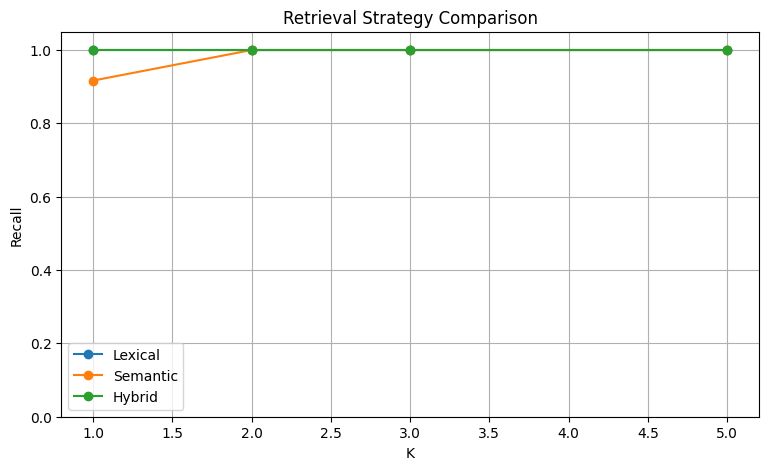

In [61]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    retrieval_comparison["K"],
    retrieval_comparison["Lexical"],
    marker="o",
    label="Lexical"
)

plt.plot(
    retrieval_comparison["K"],
    retrieval_comparison["Semantic"],
    marker="o",
    label="Semantic"
)

plt.plot(
    retrieval_comparison["K"],
    retrieval_comparison["Hybrid"],
    marker="o",
    label="Hybrid"
)

plt.xlabel(
    "K"
)

plt.ylabel(
    "Recall"
)

plt.title(
    "Retrieval Strategy Comparison"
)

plt.ylim(
    0,
    1.05
)

plt.legend()

plt.grid(
    True
)

plt.show()

In [62]:
def build_context(
    query,
    top_k=3
):

    results = hybrid_search(
        query,
        top_k
    )

    context = []

    for _, row in results.iterrows():

        context.append(
            f"Code: {row['code']}\n"
            f"Title: {row['title']}\n"
            f"Definition: {row['definition']}"
        )

    return "\n\n".join(
        context
    )

In [63]:
def build_rag_prompt(
    query,
    top_k=3
):

    context = build_context(
        query,
        top_k
    )

    return f"""
You are an occupation classification assistant.

Classify the worker description using ONLY
the retrieved candidate occupations.

Worker description:
{query}

Retrieved candidates:
{context}

Instructions:
1. Select the best matching occupation.
2. Do not invent an occupation code.
3. Use only a retrieved code.
4. If evidence is insufficient, request human review.

Output format:

CODE: <occupation code>
REASON: <short explanation>
""".strip()

In [64]:
def classify_with_confidence(
    query
):

    results = hybrid_search(
        query,
        top_k=2
    )

    best = results.iloc[0]

    best_score = float(
        best["hybrid_score"]
    )

    if len(results) > 1:

        second_score = float(
            results.iloc[1][
                "hybrid_score"
            ]
        )

    else:
        second_score = 0.0

    margin = (
        best_score
        - second_score
    )

    uncertain = (
        best_score
        < CONFIG[
            "confidence_threshold"
        ]
        or
        margin
        < CONFIG[
            "margin_threshold"
        ]
    )

    decision = (
        "HUMAN_REVIEW"
        if uncertain
        else "AUTO_CODE"
    )

    return {
        "code":
            best["code"],

        "title":
            best["title"],

        "confidence":
            best_score,

        "margin":
            margin,

        "decision":
            decision
    }

In [65]:
def rag_pipeline(
    query
):

    query_clean = clean_text(
        query
    )

    if not query_clean:
        raise ValueError(
            "Query cannot be empty."
        )

    retrieval_results = hybrid_search(
        query,
        CONFIG["top_k"]
    )

    prediction = classify_with_confidence(
        query
    )

    prompt = build_rag_prompt(
        query,
        CONFIG["top_k"]
    )

    return {
        "query":
            query,

        "prediction":
            prediction["code"],

        "title":
            prediction["title"],

        "confidence":
            prediction["confidence"],

        "margin":
            prediction["margin"],

        "decision":
            prediction["decision"],

        "retrieved_codes":
            retrieval_results[
                "code"
            ].tolist(),

        "prompt":
            prompt
    }

In [66]:
def demo(
    query
):

    result = rag_pipeline(
        query
    )

    print(
        "=" * 60
    )

    print("INPUT")
    print(query)

    print()

    print(
        "RETRIEVED CANDIDATES"
    )

    display(
        hybrid_search(
            query,
            CONFIG["top_k"]
        )
    )

    print()

    print(
        "FINAL RESULT"
    )

    print(
        "Code:",
        result["prediction"]
    )

    print(
        "Occupation:",
        result["title"]
    )

    print(
        "Confidence:",
        round(
            result["confidence"],
            3
        )
    )

    print(
        "Top-2 margin:",
        round(
            result["margin"],
            3
        )
    )

    print(
        "Decision:",
        result["decision"]
    )

    visualize_search(
        query,
        top_k=5
    )

INPUT

    I work with equipment and help
    fix different things.
    

RETRIEVED CANDIDATES


,code,title,definition,lexical_score,semantic_score,hybrid_score
0,OCC004,Teacher,"Educates students, prepares lessons, evaluates...",0.134975,0.560120,0.368805
1,OCC009,Data Analyst,"Collects, analyzes, interprets, and reports da...",0.130031,0.562743,0.368023
2,OCC012,Mechanical Engineer,"Designs, develops, tests, and evaluates mechan...",0.100965,0.509756,0.325800



FINAL RESULT
Code: OCC004
Occupation: Teacher
Confidence: 0.369
Top-2 margin: 0.001
Decision: HUMAN_REVIEW


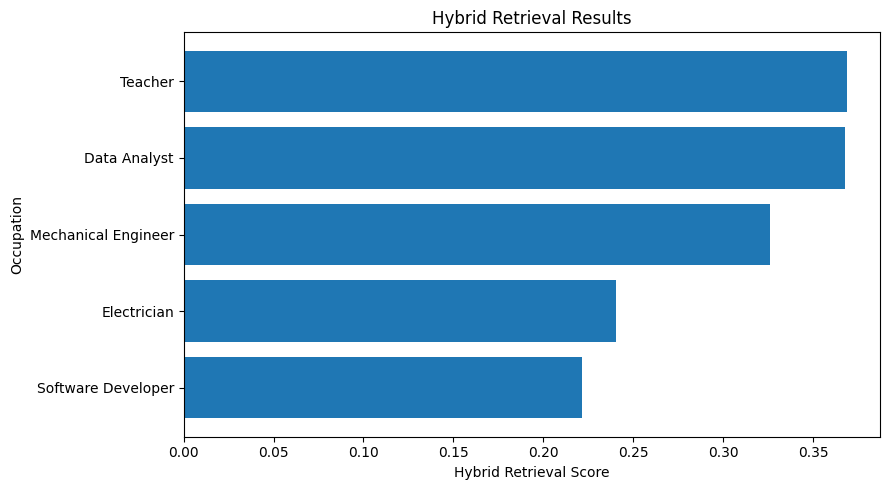

In [67]:
demo(
    """
    I work with equipment and help
    fix different things.
    """
)

In [68]:
pipeline_logs = []

In [69]:
def logged_rag_pipeline(
    query
):

    result = rag_pipeline(
        query
    )

    log = {
        "timestamp":
            datetime.now(
                timezone.utc
            ).isoformat(),

        "pipeline_version":
            CONFIG["version"],

        "query":
            query,

        "prediction":
            result["prediction"],

        "confidence":
            result["confidence"],

        "margin":
            result["margin"],

        "decision":
            result["decision"],

        "retrieved_codes":
            "|".join(
                result[
                    "retrieved_codes"
                ]
            )
    }

    pipeline_logs.append(
        log
    )

    return result

In [70]:
demo_queries = [
    "I repair electrical wiring.",

    "I take care of patients.",

    "I write computer programs.",

    "I teach children.",

    "I prepare company taxes.",

    "I install pipes.",

    "I cook restaurant meals.",

    "I analyze company data.",

    "I recruit employees.",

    "I design machines.",

    "I help with different things."
]


for query in demo_queries:

    logged_rag_pipeline(
        query
    )


logs_df = pd.DataFrame(
    pipeline_logs
)

logs_df

,timestamp,pipeline_version,query,prediction,confidence,margin,decision,retrieved_codes
0,2026-09-27T01:06:49.290044+00:00,2.0.0,I repair electrical wiring.,OCC001,0.776908,0.231885,AUTO_CODE,OCC001|OCC007|OCC005
1,2026-09-27T01:06:49.309720+00:00,2.0.0,I take care of patients.,OCC002,0.683733,0.522428,AUTO_CODE,OCC002|OCC004|OCC009
2,2026-09-27T01:06:49.326635+00:00,2.0.0,I write computer programs.,OCC003,0.648069,0.117472,AUTO_CODE,OCC003|OCC012|OCC001
3,2026-09-27T01:06:49.342296+00:00,2.0.0,I teach children.,OCC012,0.000000,0.000000,HUMAN_REVIEW,OCC012|OCC011|OCC010
4,2026-09-27T01:06:49.357672+00:00,2.0.0,I prepare company taxes.,OCC006,0.647634,0.438316,AUTO_CODE,OCC006|OCC004|OCC009
5,2026-09-27T01:06:49.375698+00:00,2.0.0,I install pipes.,OCC007,0.657852,0.123965,AUTO_CODE,OCC007|OCC001|OCC005
6,2026-09-27T01:06:49.392571+00:00,2.0.0,I cook restaurant meals.,OCC008,0.701930,0.681853,AUTO_CODE,OCC008|OCC001|OCC006
7,2026-09-27T01:06:49.409467+00:00,2.0.0,I analyze company data.,OCC009,0.713707,0.594285,AUTO_CODE,OCC009|OCC006|OCC002
8,2026-09-27T01:06:49.425446+00:00,2.0.0,I recruit employees.,OCC012,0.000000,0.000000,HUMAN_REVIEW,OCC012|OCC011|OCC010
9,2026-09-27T01:06:49.442020+00:00,2.0.0,I design machines.,OCC012,0.650389,0.114388,AUTO_CODE,OCC012|OCC003|OCC001


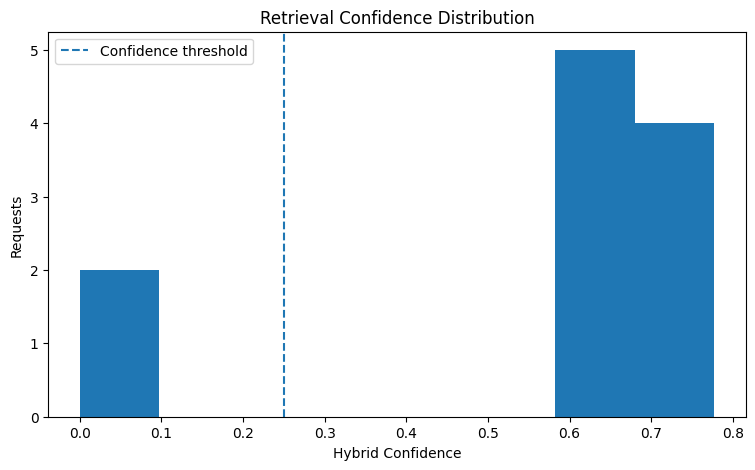

In [71]:
plt.figure(
    figsize=(9, 5)
)

plt.hist(
    logs_df["confidence"],
    bins=8
)

plt.axvline(
    CONFIG[
        "confidence_threshold"
    ],
    linestyle="--",
    label="Confidence threshold"
)

plt.xlabel(
    "Hybrid Confidence"
)

plt.ylabel(
    "Requests"
)

plt.title(
    "Retrieval Confidence Distribution"
)

plt.legend()

plt.show()

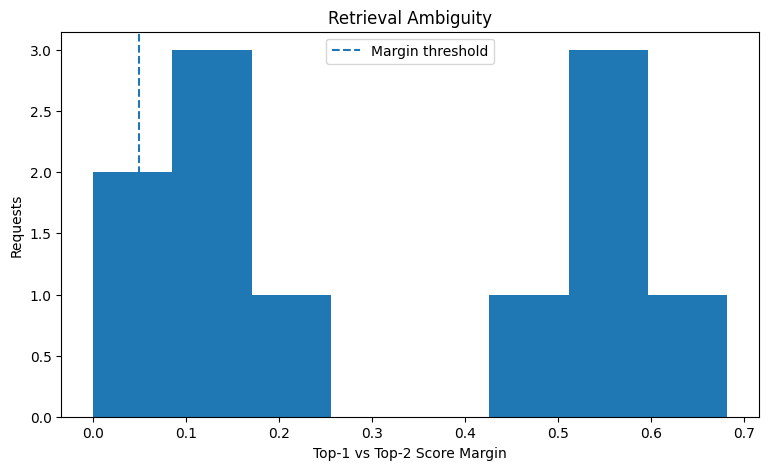

In [72]:
plt.figure(
    figsize=(9, 5)
)

plt.hist(
    logs_df["margin"],
    bins=8
)

plt.axvline(
    CONFIG[
        "margin_threshold"
    ],
    linestyle="--",
    label="Margin threshold"
)

plt.xlabel(
    "Top-1 vs Top-2 Score Margin"
)

plt.ylabel(
    "Requests"
)

plt.title(
    "Retrieval Ambiguity"
)

plt.legend()

plt.show()

In [73]:
auto_rate = (
    logs_df["decision"]
    ==
    "AUTO_CODE"
).mean()

review_rate = (
    logs_df["decision"]
    ==
    "HUMAN_REVIEW"
).mean()


print(
    f"Auto-code rate: {auto_rate:.2%}"
)

print(
    f"Human review rate: {review_rate:.2%}"
)

Auto-code rate: 81.82%
Human review rate: 18.18%


In [74]:
mrr = mean_reciprocal_rank(golden_data)

evaluation_summary = pd.DataFrame({
    "Metric": [
        "Recall@1",
        "Recall@3",
        "MRR",
        "Auto-Code Rate",
        "Human Review Rate"
    ],

    "Value": [
        recall_at_k(
            golden_data,
            1
        ),

        recall_at_k(
            golden_data,
            3
        ),

        mrr,

        auto_rate,

        review_rate
    ]
})

evaluation_summary

,Metric,Value
0,Recall@1,1.000000
1,Recall@3,1.000000
2,MRR,1.000000
3,Auto-Code Rate,0.818182
4,Human Review Rate,0.181818


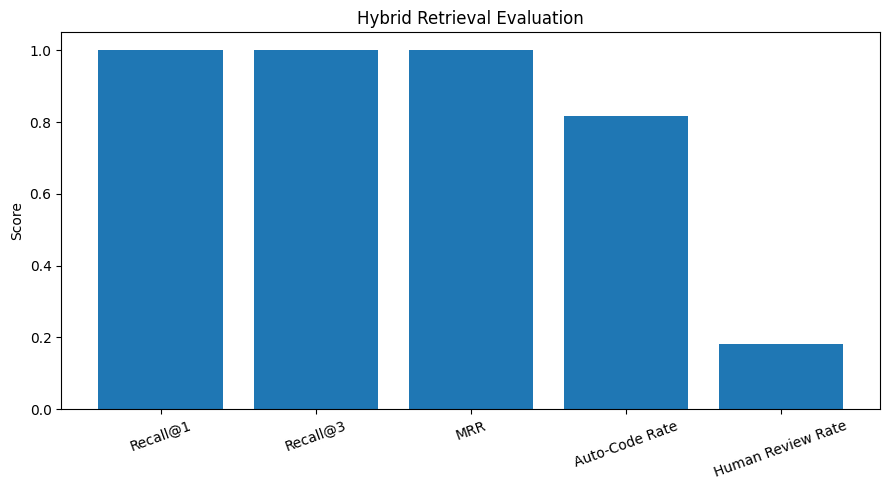

In [75]:
plt.figure(
    figsize=(9, 5)
)

plt.bar(
    evaluation_summary["Metric"],
    evaluation_summary["Value"]
)

plt.ylim(
    0,
    1.05
)

plt.ylabel(
    "Score"
)

plt.title(
    "Hybrid Retrieval Evaluation"
)

plt.xticks(
    rotation=20
)

plt.tight_layout()

plt.show()

In [76]:
knowledge_base.to_csv(
    ARTIFACT_DIR /
    "knowledge_base.csv",
    index=False
)

golden_data.to_csv(
    ARTIFACT_DIR /
    "golden_evaluation_data.csv",
    index=False
)

retrieval_comparison.to_csv(
    ARTIFACT_DIR /
    "retrieval_comparison.csv",
    index=False
)

logs_df.to_csv(
    ARTIFACT_DIR /
    "pipeline_logs.csv",
    index=False
)

evaluation_summary.to_csv(
    ARTIFACT_DIR /
    "evaluation_summary.csv",
    index=False
)

print(
    "CSV artifacts saved."
)

CSV artifacts saved.


In [77]:
experiment_report = {
    "timestamp":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "project":
        CONFIG["project"],

    "pipeline_version":
        CONFIG["version"],

    "retrieval": {
        "lexical_weight":
            CONFIG[
                "lexical_weight"
            ],

        "semantic_weight":
            CONFIG[
                "semantic_weight"
            ],

        "top_k":
            CONFIG["top_k"]
    },

    "guardrails": {
        "confidence_threshold":
            CONFIG[
                "confidence_threshold"
            ],

        "margin_threshold":
            CONFIG[
                "margin_threshold"
            ]
    },

    "metrics": {
        "recall_at_1":
            float(
                recall_at_k(
                    golden_data,
                    1
                )
            ),

        "recall_at_3":
            float(
                recall_at_k(
                    golden_data,
                    3
                )
            ),

        "mrr":
            float(mrr),

        "auto_code_rate":
            float(auto_rate),

        "human_review_rate":
            float(review_rate)
    }
}

In [78]:
report_path = (
    ARTIFACT_DIR /
    "experiment_report.json"
)

with open(
    report_path,
    "w"
) as file:

    json.dump(
        experiment_report,
        file,
        indent=4
    )

print(
    "Saved:",
    report_path
)

Saved: hybrid_rag_artifacts/experiment_report.json


In [79]:
def smoke_test():

    result = rag_pipeline(
        "I install and repair water pipes."
    )

    assert (
        result["prediction"]
        == "OCC007"
    )

    assert (
        result["title"]
        == "Plumber"
    )

    assert (
        len(
            result[
                "retrieved_codes"
            ]
        )
        ==
        CONFIG["top_k"]
    )

    assert (
        0
        <= result["confidence"]
        <= 1
    )

    assert (
        result["margin"]
        >= 0
    )

    assert (
        result["decision"]
        in {
            "AUTO_CODE",
            "HUMAN_REVIEW"
        }
    )

    recall3 = recall_at_k(
        golden_data,
        3
    )

    assert (
        0
        <= recall3
        <= 1
    )

    assert (
        report_path.exists()
    )

    print(
        "✅ Hybrid RAG retrieval demo passed."
    )


smoke_test()

✅ Hybrid RAG retrieval demo passed.
